In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise Separable Convolution module.
    Factorizes standard convolution into a depthwise convolution followed by a pointwise convolution
    to significantly reduce computational complexity.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dilation=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size,
                                   stride=stride, padding=padding, dilation=dilation,
                                   groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x)

class ASPP(nn.Module):
    """
    Atrous Spatial Pyramid Pooling (ASPP) module.
    Probes convolutional features at multiple scales by applying atrous convolution with different rates,
    incorporating image-level features for global context.
    """
    def __init__(self, in_channels, out_channels):
        super(ASPP, self).__init__()
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv3x3_1 = DepthwiseSeparableConv(in_channels, out_channels, padding=6, dilation=6)
        self.conv3x3_2 = DepthwiseSeparableConv(in_channels, out_channels, padding=12, dilation=12)
        self.conv3x3_3 = DepthwiseSeparableConv(in_channels, out_channels, padding=18, dilation=18)
        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        size = x.shape[2:]
        out1 = self.conv1x1(x)
        out2 = self.conv3x3_1(x)
        out3 = self.conv3x3_2(x)
        out4 = self.conv3x3_3(x)
        out5 = self.global_avg_pool(x)
        out5 = F.interpolate(out5, size=size, mode='bilinear', align_corners=False)
        cat_out = torch.cat([out1, out2, out3, out4, out5], dim=1)
        return self.project(cat_out)

class DeepLabV3Plus(nn.Module):
    """
    Custom DeepLabV3+ Encoder-Decoder Architecture.
    Utilizes a simplified CNN backbone for feature extraction, an ASPP module for multi-scale
    context, and a decoder module for boundary refinement.
    """
    def __init__(self, num_classes=21):
        super(DeepLabV3Plus, self).__init__()

        self.initial_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            DepthwiseSeparableConv(32, 64, stride=2)
        )

        self.low_level_features = DepthwiseSeparableConv(64, 128)

        self.high_level_features = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DepthwiseSeparableConv(128, 256),
            DepthwiseSeparableConv(256, 512, dilation=2, padding=2)
        )

        self.aspp = ASPP(in_channels=512, out_channels=256)

        self.reduce_low_level = nn.Sequential(
            nn.Conv2d(128, 48, kernel_size=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )

        self.decoder_conv = nn.Sequential(
            DepthwiseSeparableConv(256 + 48, 256),
            DepthwiseSeparableConv(256, 256),
            nn.Conv2d(256, num_classes, kernel_size=1)
        )

    def forward(self, x):
        input_size = x.shape[2:]

        x1 = self.initial_conv(x)
        low_level_feat = self.low_level_features(x1)
        high_level_feat = self.high_level_features(low_level_feat)

        aspp_out = self.aspp(high_level_feat)
        aspp_upsampled = F.interpolate(aspp_out, size=low_level_feat.shape[2:], mode='bilinear', align_corners=False)
        low_level_reduced = self.reduce_low_level(low_level_feat)

        concat_feat = torch.cat([aspp_upsampled, low_level_reduced], dim=1)
        decoder_out = self.decoder_conv(concat_feat)
        out = F.interpolate(decoder_out, size=input_size, mode='bilinear', align_corners=False)

        return out

In [8]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

target_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

# Initializing the PASCAL VOC 2012 dataset
train_dataset = datasets.VOCSegmentation(
    root='./data', year='2012', image_set='train',
    download=True, transform=transform, target_transform=target_transform
)

# Isolating a small sample batch to validate architectural convergence
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.squeeze(1).long().to(device)

In [9]:
import torch.optim as optim

# Configuring classification scope (20 PASCAL VOC classes + 1 background)
num_classes = 21
model = DeepLabV3Plus(num_classes=num_classes).to(device)

# Initializing objective function, ignoring VOC boundary indices (255)
criterion = nn.CrossEntropyLoss(ignore_index=255)
optimizer = optim.Adam(model.parameters(), lr=0.005)

num_epochs = 100
loss_history = []

model.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, masks)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:03d}/{num_epochs}], CrossEntropy Loss: {loss.item():.4f}")

Epoch [010/100], CrossEntropy Loss: 0.1600
Epoch [020/100], CrossEntropy Loss: 0.0558
Epoch [030/100], CrossEntropy Loss: 0.0337
Epoch [040/100], CrossEntropy Loss: 0.0244
Epoch [050/100], CrossEntropy Loss: 0.0170
Epoch [060/100], CrossEntropy Loss: 0.0138
Epoch [070/100], CrossEntropy Loss: 0.0112
Epoch [080/100], CrossEntropy Loss: 0.0103
Epoch [090/100], CrossEntropy Loss: 0.0084
Epoch [100/100], CrossEntropy Loss: 0.0077


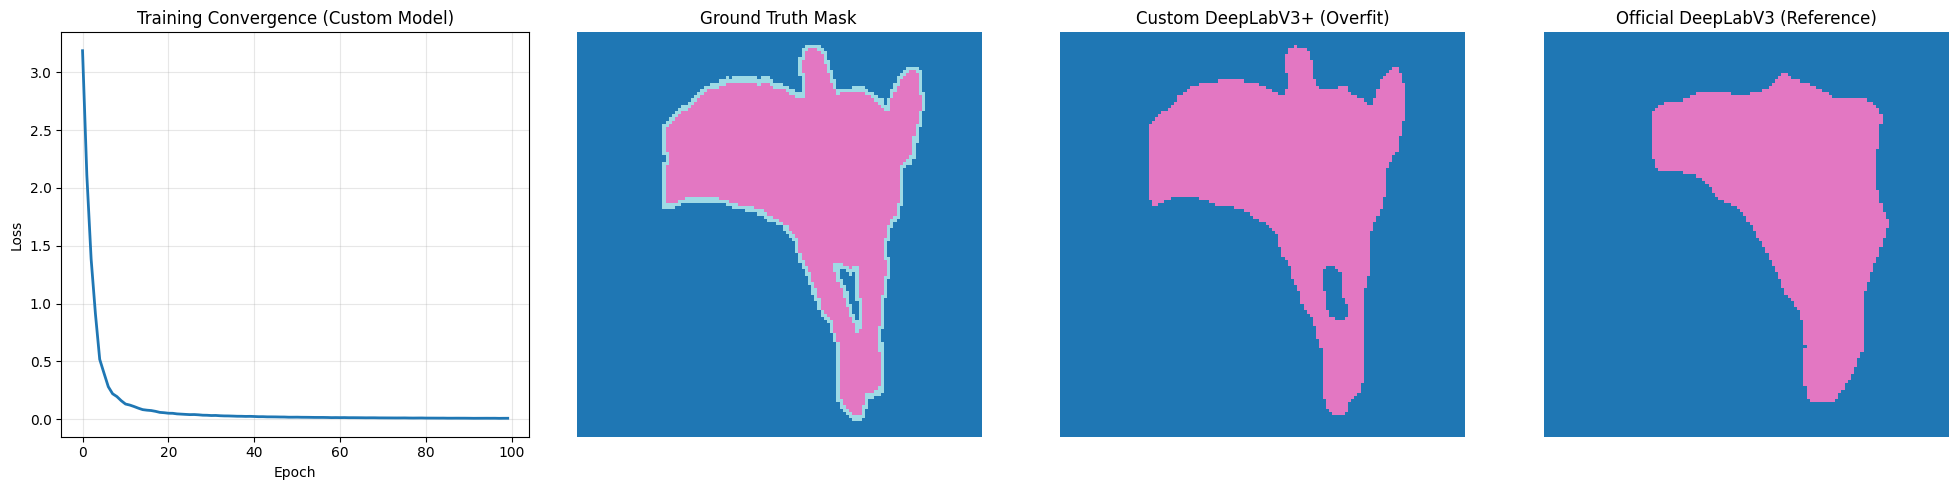

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

# --- 1. Custom Implementation ---
model.eval()
with torch.no_grad():
    sample_img = images[0:1]
    pred = model(sample_img)
    custom_pred_mask = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()
    true_mask = masks[0].cpu().numpy()

# --- 2. Official Reference Implementation ---
weights = DeepLabV3_ResNet50_Weights.DEFAULT
official_model = deeplabv3_resnet50(weights=weights).to(device)
official_model.eval()

# Applying requisite ImageNet normalization for the official model
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
sample_img_norm = normalize(sample_img.squeeze(0)).unsqueeze(0)

with torch.no_grad():
    official_out = official_model(sample_img_norm)['out']
    official_pred_mask = torch.argmax(official_out, dim=1).squeeze(0).cpu().numpy()

# --- 3.Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].plot(loss_history, color='#1f77b4', linewidth=2)
axes[0].set_title("Training Convergence (Custom Model)", fontsize=12)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=20)
axes[1].set_title("Ground Truth Mask", fontsize=12)
axes[1].axis('off')

axes[2].imshow(custom_pred_mask, cmap='tab20', vmin=0, vmax=20)
axes[2].set_title("Custom DeepLabV3+ (Overfit)", fontsize=12)
axes[2].axis('off')

axes[3].imshow(official_pred_mask, cmap='tab20', vmin=0, vmax=20)
axes[3].set_title("Official DeepLabV3 (Reference)", fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.show()

In [11]:
from google.colab import files

model_save_name = 'custom_deeplabv3plus_weights_final.pth'

# Saving the learned parameters
torch.save(model.state_dict(), model_save_name)
print(f"Model state dictionary saved successfully to {model_save_name}")

# Download
files.download(model_save_name)

Model state dictionary saved successfully to custom_deeplabv3plus_weights_final.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>